<a href="https://colab.research.google.com/github/CookOLo/MAT422/blob/main/HW_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.2 - Probability distribution


## 2.2.1 - Probability
**Definition 2.2.1.** The **sample space** of an experiment, denoted by S, is
the set of all possible outcomes of that experiment.

**Definition 2.2.2.** An event is any collection (subset) of outcomes contained in the sample space S. An event is **simple** if it consists of exactly one outcome and **compound** if it consists of more than one outcome.

**Definition 2.2.3**. Given an experiment and a sample space S, the probability distribution is a function which assigns to each event A a number P(A), called the probability of the event A, which will give a precise measure of the chance that A will occur. The probability assignments should satisfy the following axioms (basic properties) of probability:

• For any event $A, 1 ≥ P(A) ≥ 0$

• $P(S) = 1$
• If $A1, A2, A3, . . .$ is an infinite collection of disjoint events, then


$$P (A1 ∪ A2 ∪ A3 ∪ · · · ) = ∞∑ i=1 P (A i)$$


• For any event A, $P(A) + P (A′) = 1$, from which $P(A) = 1 − P (A′)$
• When events A and B are mutually exclusive,

$$P(A ∪ B) = P(A) + P(B)$$

• For any two events A and B,

$$P(A ∪ B) = P(A) + P(B) − P(A ∩ B)$$

**Example 2.2.4.** In a simply and yet common experiment consisting of
N outcomes, it is reasonable to assign equal probabilities to all N simple
events. That is, if there are N equally likely outcomes, the probability for
each is $1/N$. Now consider an event A, with N(A) denoting the number
of outcomes contained in A and we have
$$P(A) = (N(A))/N$$

In [ ]:
# Sample space of a collection of colors that I see around me
sample = ["black", "black", "black", "white", "white", "gray", "gray", "white", "black", "red", "blue"]

# Get the colors separated as categories
colors = []
for i in sample:
  if i not in colors:
    colors.append(i);

# Get the number of how many colors are shown
count = [];
for i in colors:
  count.append(0);

for i in sample:
  if i in colors:
    count[colors.index(i)] += 1;

# Print
for i in range(len(colors)):
  print("The probability of me seeing " + colors[i] + " right now is " + str(count[i]/len(sample)));


The probability of me seeing black right now is 0.36363636363636365
The probability of me seeing white right now is 0.2727272727272727
The probability of me seeing gray right now is 0.18181818181818182
The probability of me seeing red right now is 0.09090909090909091
The probability of me seeing blue right now is 0.09090909090909091


## 2.2.2 - Conditional proability
**Definition 2.2.5.**: For any two events $A$ and $B$ with $P(B) > 0$, the conditional probability of $A$ given that $B$ has occurred is defined by

$$P(A | B) = \frac{P(A ∩ B)}{P(B)}$$


Conditional probability gives a rise to the multiplication rule,
$$P(A ∩ B) = P(A | B) · P(B).$$


**Definition 2.2.6.** Two events $A$ and $B$ are independent if $P(A | B) =
P(A)$ (or $P(A ∩ B) = P(A) · P(B)$), and are dependent otherwise.

In [1]:
## If there are two independent events, what is the probability Event A will occur given that event B has already occurred?
coinFlip = .5;   # Event A is Coin flip on Head
dieSix = 1/6;    # Event B is Die Roll on 6

probTogether = coinFlip * dieSix;   # Event A and Event B happening at the same time

condProb = probTogether / dieSix;

print("The probability of a coin landing on heads happening given that a die rolled a six has already occurred is " + str(condProb));

The probability of a coin landing on heads happening given that a die rolled a six has already occurred is 0.5


In [2]:
### If there are two dependent events, what is the probability Event A will occur given that event B has already occurred?

basketOnly = 60/200; # 60/200 students play basketball
tallOnly = 40/200; # 40/200 students are 6 foot tall
both = 30/200; # 30/200 students play basketball and are 6 foot tall

condProb = both / tallOnly;

print("The probability of a student playing basketball given that they are 6 foot tall is " + str(condProb));

The probability of a student playing basketball given that they are 6 foot tall is 0.7499999999999999


**Definition 2.2.7.** Events $A_1, . . ., A_n$ are mutually independent if for
every $k(k = 2, 3, . . ., n)$ and every subset of indices $i_1, i_2, . . ., i_k$,

$$P(A_{i_1} ∩ A_{i_2} ∩ . . . ∩ A_{i_k}) = P (A_{i_1}) · P (A_{i_2}) · · · · · · P(A_{i_k})$$

## 2.2.3 - Discrete random variables
Definition 2.2.8: **Random variable** - a function whose domain is the sample space and whose range is the set of real numbers
- Types:
  - *Discrete random variable*: a random variable whose possible vectors either constitute a finite set or else can be listed in an inifinite sequence
  - *Continuous random variable*:
    1. Its set of possible values consists all numbers in a single interval on the number line
    2. $P(X = C) = 0$ for any possible value individual $c$

**Definition 2.2.10.** The probability distribution or probability mass
function (pmf) of a discrete random variable is defined for every number x by
$$p(x) = P(X = x) = P(all\;s ∈ S : X(s) = x).$$

**Definition 2.2.11.** The cumulative distribution function (cdf) $F(x)$ of a
discrete random variable X with pmf $p(x)$ is defined for every number x by

$$F(x) = P(X ≤ x) = \sum_{y:y≤x} p(y).$$

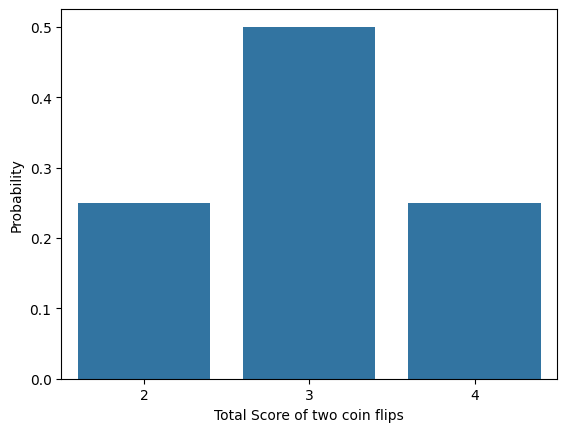

In [7]:
from itertools import product
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## PMF of 2 coin flips
### Possible Outcomes: {HH, HT, TH, TT}

types = ['Heads', 'Tails'];

# Assigning scores to each type
type_scores = dict(zip(types, range(1, 3)))

# Computing overall scores for 2 coin flips
X_omega = {
    (type1, type2): type_scores[type1] + type_scores[type2]
    for type1, type2 in product(types, repeat=2)

}

# Total elements in space
total_sample_outcomes = len(X_omega)

# Counting frequencies of each value the random variable can assume
frequencies = dict.fromkeys(X_omega.values(), 0)
for sample_outcome, overall_score in X_omega.items():
    frequencies[overall_score] += 1;

# Computing probabilities
probabilities = pd.DataFrame(
    data=[
        [value, frequency / total_sample_outcomes]
        for value, frequency in frequencies.items()
    ],
    columns=['Total Score of two coin flips', 'Probability']

)

# Plotting PMF as a Bar Graph
ax = sns.barplot(
    x='Total Score of two coin flips',
    y='Probability',
    data=probabilities,
)
plt.savefig("pmf")


### 2.2.3.1 - The Expected value and variance of X
**Definition 2.2.14.** Let $X$ be a discrete random variable with set of possible values $D$ and pmf $p(x)$. The expected value or mean value of $X$, denoted by $E(X)$ or $μ_X$ or just $μ$, is

$$E(X) = μ_X = \sum_{x∈D} x · p(x).$$

**Proposition 2.2.16.** If the random variable X has a set of possible values $D$ and pmf $p(x)$, then the expected value of any function $h(X)$, denoted by $E[h(X)]$ or $μ_{h(X)}, is computed by

$$E[h(X)] = \sum_{D} h(x) · p(x).$$
In particular,

$$E(aX + b) = a · E(X) + b.$$

Variances measure how far a set of numbers is spread out from their
average value.

**Definition 2.2.17.** Let $X$ have pmf $p(x)$ and expected value $μ.$ Then the
variance of $X$, denoted by $V(X)$ or $σ_{X}^{2}$ , or just $σ_2$, is

$$V (X) = \sum_{D} (x − μ)2 · p(x) = E [(X − μ)2]$$

The **standard deviation** (SD) of X is

$$σ_X = \sqrt{σ_{X}^{2}}.$$

**Proposition 2.2.18.**
$$V(aX + b) = σ^2_{aX+b} = a^2 · σ^2_{X}\;and\;σ_{aX+b} = |a| · σ_x.$$

In particular,

$$σ_{aX} = |a| · σ_X,\;σ_{X+b} = σ_X.$$

It is useful to know expected values and variances of the two important
distributions.

**Proposition 2.2.19.**

- If $X$ is a binomial random variable with parameters $n$, $p$, then, $E(X) = np,
\;V(X) = np(1 − p),\;σ_X = \sqrt{np(1 − p)}.$
- If $X$ is a Poisson distribution with parameter $μ$, then $E(X) = μ, V (X) = μ$.

# 2.2.4 - Continues random variables

**Definition 2.2.20.** Let X be a continuous random variable. Then a prob-
ability distribution or probability density function (pdf) of $X$ is a
function $f(x)$ such that for any two numbers $a$ and $b$ with $a ≤ b$,

$$P(a ≤ X ≤ b) = \int_b^a f (x)dx.$$

That is, the probability that X takes on a value in the interval [a, b] is the
area above this interval and under the graph of the density function, as
illustrated in Fig. 2.3. f (x) must satisfy the following two conditions:
1. $f (x) ≥ 0$ for all $x$
2. $\int_{-∞}^∞ f(x)\;dx$ = Total area under the entire graph of $f(x)$

**Definition 2.2.21.** The expected or mean value of a continuous ran-
dom variable $X$ with pdf $f(x)$ is

$$μ_X = E(X) = \int_{-∞}^∞ x · f (x)\;dx.$$

**Definition 2.2.22.** The variance of a continuous random variable X with
pdf $f(x)$ and the variance is $μ$ is

$$σ_2^X = V (X) = \int_{-∞}^∞ (x − μ)^2 · f(x)\;dx = E [(X − μ)^2]$$


The standard deviation (SD) of $X$ is $σ_X = \sqrt{V (X)}$.

**Definition 2.2.24.** $X$ is said to have an exponential distribution with
parameter $λ(λ > 0)$ if the pdf of $X is

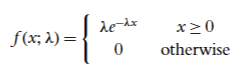

The expected value of an exponentially distributed random variable X
is

$$E(X) = \int_0^∞ xλe^{−λx}\;dx$$

### 2.2.4.2 - The normal distribution

**Definition 2.2.25.** A continuous random variable X is said to have a
normal distribution with parameters $μ$ and $σ$ (or $μ$ and $σ_2$ ), where

$−∞ < μ < ∞$ and $0 < σ$, if the pdf of $X$ is

$$f (x; μ, σ ) = \frac{1}{\sqrt{2πσ}} e^{−(x−μ)^2/(2σ^2)}\;− ∞ < x < ∞.$$


The computation of $P(a ≤ X ≤ b)$ when $X$ is a normal random variable
with parameters $μ$ and $σ$ requires evaluating

$$\int_a^b  \frac{1}{\sqrt{2πσ}} e^{−(x−μ)^2/(2σ^2)}\;dx.$$

**Definition 2.2.26.** The normal distribution with parameter values $μ = 0$
and $σ = 1$ is called the standard normal distribution. A random variable
having a standard normal distribution is called a standard normal ran-
dom variable and will be denoted by $Z$. The pdf of $Z$ is

$$f(z; 0, 1) = \frac{1}{\sqrt{2π}} e^{−z^2/2}\;− ∞ < z < ∞.$$

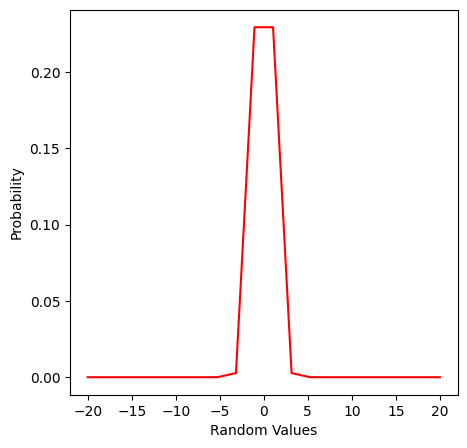

In [1]:
## Normal Distribution Graph
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

mean = 0
std = 1
snd = stats.norm(mean, std)

# Generating 20 random vaues between -20 and 20
x = np.linspace(-20, 20, 20)

# Plotting normal distribution graph with ^ specifications
plt.figure(figsize=(5, 5))
plt.plot(x, snd.pdf(x), color='red')
plt.xlabel('Random Values')
plt.ylabel('Probability')
plt.show()